# Máquinas Térmicas - Lección 10b (Bonus)
## Cinemática y cinética del mecanismo de un motor de compresión variable (VCR)

**Autores del informe original:** Lina Sofía Alarcón Benites y Hader Chilatra Ducuara (Estática, PUJ, 28/05/2025)
**Adaptación AVA:** Camilo Bayona

### Objetivos de aprendizaje
1. Reconocer un mecanismo real de motor de **relación de compresión variable** (VCR) como una generalización del sistema biela-manivela-pistón simple de las Lecciones 10-11.
2. Plantear y resolver el análisis de posición de un mecanismo multibarra mediante **ecuaciones de lazo vectorial** y el **método del jacobiano** (posición → velocidad → aceleración).
3. Explicar físicamente por qué variar la distancia $R_{OE}$ entre los dos pivotes fijos cambia la relación de compresión, y por qué existe un límite geométrico (bloqueo del mecanismo) al reducirla demasiado.
4. Visualizar, mediante widgets animados, el movimiento del mecanismo completo y el efecto de $R_{OE}$ y de la velocidad de giro sobre la posición, velocidad y aceleración del pistón.

In [1]:
# Instalación solo en Google Colab; en el entorno local del curso es un no-op
import sys
if "google.colab" in sys.modules:
    import subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "matplotlib", "ipywidgets", "numpy", "scipy"], check=True)

In [2]:
# === Setup =================================================================
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import fsolve
from scipy.integrate import trapezoid
from ipywidgets import (interact, interactive_output, FloatSlider, IntSlider,
                        Dropdown, Checkbox, Play, HBox, VBox, jslink)
from IPython.display import display

# fsolve a veces reporta "poco progreso" al converger sobre una rama con múltiplos
# de 2π de más (ver nota en resolver_posicion) -- el resultado sigue siendo válido.
warnings.filterwarnings("ignore", message="The iteration is not making good progress")

# Paleta del proyecto (misma que Lecciones 7-10; roles nuevos para este mecanismo)
COL = {"aire": "#2a78d6", "abierta": "#1baf7a", "cerrada": "#8a8a86", "perdida": "#e34948",
       "manivela": "#2a78d6", "biela1": "#4a3aa7", "balancin": "#1baf7a", "biela2": "#eb6834",
       "metal": "#c3c2b7", "tinta": "#3a3a38", "aviso": "#e34948"}

# --- Geometría asumida (SI, metros) -----------------------------------------
# El informe original NO publica las longitudes de los eslabones (solo viven en un
# modelo SolidWorks y un Excel enlazados externamente, inaccesibles desde aquí).
# Se asumen valores propios, declarados explícitamente, elegidos para que el
# mecanismo cumpla la condición de Grashof (manivela de vuelta completa) en todo
# el rango de R_OE ensayado por los autores (65-85 mm) y para que el margen de
# Grashof se encoja hacia R_OE pequeño -- reproduciendo su hallazgo cualitativo
# de "señales de posible bloqueo" mediante el ángulo de transmisión real.
R_OC = 0.035   # manivela O-C (entrada)
R_CA = 0.095   # acoplador, tramo C-A
R_AB = 0.025   # acoplador, tramo A-B (extensión rígida del mismo eslabón "barra AB")
R_CB = R_CA + R_AB
R_AE = 0.075   # balancín A-E
R_BD = 0.110   # biela secundaria B-D (al pistón)

# Masas e inercias -- SÍ publicadas en el informe (Cuadro 5), reutilizadas tal cual (SI)
m_OC, m_AE, m_AB, m_BD, m_p = 0.01623, 0.08358, 0.06689, 0.10811, 0.17663   # kg
I_OC, I_AE, I_AB, I_BD = 1.218e-6, 4.342e-5, 3.053e-5, 6.354e-5             # kg·m²
g = 9.81

print("Setup OK — geometría asumida, inercias del Cuadro 5 del informe")

Setup OK — geometría asumida, inercias del Cuadro 5 del informe


## 1. Contexto: de la manivela fija a un motor de compresión variable

Desde la Lección 10, el pistón se ha movido con el sistema biela-manivela más simple posible: una manivela de longitud fija empuja una biela que empuja el pistón, y la relación de compresión $r$ queda congelada por la geometría desde el diseño. Los motores **VCR** (*Variable Compression Ratio*) reales rompen esa rigidez agregando una segunda etapa articulada: un cuadrilátero $O$-$C$-$A$-$E$ cuyo lado fijo $R_{OE}$ se puede desplazar, cambiando la carrera del pistón — y por tanto $r$ — sin apagar el motor. Este cuadernillo reconstruye en Python la cinemática y la cinética de ese mecanismo, a partir del informe de Estática de Lina Sofía Alarcón Benites y Hader Chilatra Ducuara (PUJ, 2025), como extensión de la Lección 10.

## 2. Arquitectura del mecanismo: dos lazos

- **Lazo 1** (cuadrilátero $O$-$C$-$A$-$E$): manivela $OC$ (entrada, $\theta_1=\omega_1 t$), acoplador $CA$, balancín $AE$, con $O$ y $E$ **fijos** y separados una distancia $R_{OE}$ (vertical). $R_{OE}$ es el parámetro de control de la compresión.
- El acoplador se extiende rígidamente desde $C$, pasando por $A$, hasta un tercer punto $B$ (mismo eslabón físico, la "barra $AB$" del informe).
- **Lazo 2** ($O$-$C$-$B$-$D$): desde $B$, una biela secundaria $BD$ mueve el **pistón $D$**, restringido a moverse solo verticalmente ($x_D=0$).

> **Nota de supuestos.** El informe original no publica $R_{OC}, R_{CA}, R_{AB}, R_{AE}, R_{BD}$ (solo $R_{OE}\in\{65,75,85\}$ mm y las masas/inercias). Los valores de la celda de Setup son una geometría propia, completamente asumida y declarada — no atribuida a los autores. Además, reimplementamos el acoplador $C$-$A$-$B$ como un **marco rígido local** (rotado por $\theta_2$) en vez de la contabilidad vectorial punto a punto del informe original: es matemáticamente equivalente, pero evita un paso de signos ambiguo del documento fuente (§1.2, $\vec R_{CB}=\vec R_{AB}-\vec R_{CA}$) y generaliza directo a cualquier geometría.

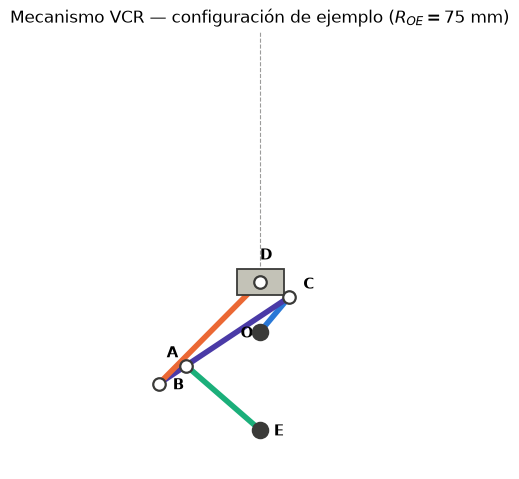

In [3]:
# Diagrama propio del mecanismo (reemplaza el boceto a mano del informe, Figura 1)
def resolver_posicion(theta1, ROE, guess):
    def eqs(x):
        th2, th3 = x
        e1 = R_OC*np.cos(theta1) + R_CA*np.cos(th2) - R_AE*np.cos(th3)
        e2 = R_OC*np.sin(theta1) + R_CA*np.sin(th2) - R_AE*np.sin(th3) + ROE
        return [e1, e2]
    sol = fsolve(eqs, guess, xtol=1e-13)
    # fsolve puede converger a una rama con múltiplos de 2π de más (misma física,
    # mismo seno/coseno, pero un ángulo feo de mostrar) -- se reduce a (-pi, pi].
    return np.mod(sol + np.pi, 2*np.pi) - np.pi

def punto_B(theta1, th2):
    Cx, Cy = R_OC*np.cos(theta1), R_OC*np.sin(theta1)
    return Cx + R_CB*np.cos(th2), Cy + R_CB*np.sin(th2)

def lazo2_posicion(Bx, By):
    c4 = -Bx/R_BD
    s4 = np.sqrt(max(0.0, 1 - c4**2))
    th4 = np.arctan2(s4, c4)
    yD = By + R_BD*s4
    return th4, yD

def dibujar_mecanismo(ax, theta1, ROE, guess=None):
    if guess is None:
        guess = np.array([np.pi*0.6, -np.pi*0.4])
    th2, th3 = resolver_posicion(theta1, ROE, guess)
    Ox, Oy = 0.0, 0.0
    Ex, Ey = 0.0, -ROE
    Cx, Cy = R_OC*np.cos(theta1), R_OC*np.sin(theta1)
    Ax, Ay = Cx + R_CA*np.cos(th2), Cy + R_CA*np.sin(th2)
    Bx, By = punto_B(theta1, th2)
    th4, Dy = lazo2_posicion(Bx, By)
    Dx = 0.0

    ax.plot([Ox, Cx], [Oy, Cy], "-", lw=4, color=COL["manivela"], solid_capstyle="round")
    ax.plot([Cx, Bx], [Cy, By], "-", lw=4, color=COL["biela1"], solid_capstyle="round")
    ax.plot([Ax, Ex], [Ay, Ey], "-", lw=4, color=COL["balancin"], solid_capstyle="round")
    ax.plot([Bx, Dx], [By, Dy], "-", lw=4, color=COL["biela2"], solid_capstyle="round")

    # desplazamientos de etiqueta afinados a mano para evitar solapes (O, C y D quedan
    # cerca entre sí con esta geometría) -- cada punto con su propio offset
    offsets = {"O": (-14, -4), "E": (10, -4), "C": (10, 6), "A": (-14, 6), "B": (10, -4), "D": (0, 16)}
    for (px, py, lbl) in [(Ox,Oy,"O"), (Ex,Ey,"E"), (Cx,Cy,"C"), (Ax,Ay,"A"), (Bx,By,"B"), (Dx,Dy,"D")]:
        fixed = lbl in ("O", "E")
        ax.plot(px, py, "o", ms=9 if not fixed else 11,
                color=COL["tinta"] if fixed else "white",
                mec=COL["tinta"], mew=1.6, zorder=5)
        ax.annotate(lbl, (px, py), textcoords="offset points", xytext=offsets[lbl],
                    fontsize=11, fontweight="bold")

    # pistón esquemático (guía vertical) alrededor de D
    ax.add_patch(plt.Rectangle((Dx-0.018, Dy-0.010), 0.036, 0.020,
                                fc=COL["metal"], ec=COL["tinta"], lw=1.3, zorder=4))
    ax.plot([Dx, Dx], [Dy+0.012, 0.25], "--", color=COL["tinta"], lw=0.8, alpha=0.5)

    ax.set_aspect("equal"); ax.set_xlim(-0.18, 0.18); ax.set_ylim(-ROE-0.03, 0.23)
    ax.axis("off")
    return dict(th2=th2, th3=th3, th4=th4, Cx=Cx, Cy=Cy, Ax=Ax, Ay=Ay, Bx=Bx, By=By, Dx=Dx, Dy=Dy)

fig, ax = plt.subplots(figsize=(5, 6))
dibujar_mecanismo(ax, theta1=np.radians(50), ROE=0.075)
ax.set_title("Mecanismo VCR — configuración de ejemplo ($R_{OE}=75$ mm)")
plt.tight_layout(); plt.show()

## 3. Ecuaciones de lazo (posición)

**Lazo 1** ($O$-$C$-$A$-$E$), cierre vectorial $\vec R_{OC}+\vec R_{CA}=\vec R_{OE}+\vec R_{AE}$, en componentes:

$$R_{OC}\cos\theta_1+R_{CA}\cos\theta_2-R_{AE}\cos\theta_3=0$$
$$R_{OC}\sin\theta_1+R_{CA}\sin\theta_2-R_{AE}\sin\theta_3=-R_{OE}$$

Dado $\theta_1$ (entrada), son 2 ecuaciones no lineales para 2 incógnitas ($\theta_2,\theta_3$) — se resuelven numéricamente (`fsolve`, celda anterior).

**Punto $B$** (marco rígido del acoplador, rotado por $\theta_2$): $\;\vec R_{OB}=\vec R_{OC}+(R_{CA}+R_{AB})(\cos\theta_2,\sin\theta_2)$.

**Lazo 2** ($B$-$D$, pistón restringido a $x_D=0$):

$$B_x+R_{BD}\cos\theta_4=0 \;\Rightarrow\; \theta_4=\arccos\!\left(\frac{-B_x}{R_{BD}}\right), \qquad y_D=B_y+R_{BD}\sin\theta_4$$

Esta segunda ecuación se resuelve **directamente** (sin `fsolve`): al ser una sola restricción escalar, despejar $\theta_4$ con $\arccos$ es exacto y más simple que el lazo vectorial 2D que usa el informe original para el mismo propósito.

## 4. Velocidad y aceleración: el método del jacobiano

Derivar las dos ecuaciones de lazo respecto al tiempo da un **sistema lineal** para $(\omega_2,\omega_3)$ en términos de $\omega_1$ (dato):

$$J(\theta_2,\theta_3)\begin{pmatrix}\omega_2\\\omega_3\end{pmatrix}=\omega_1 R_{OC}\begin{pmatrix}\sin\theta_1\\-\cos\theta_1\end{pmatrix},
\qquad
J=\begin{pmatrix}-R_{CA}\sin\theta_2 & R_{AE}\sin\theta_3\\ R_{CA}\cos\theta_2 & -R_{AE}\cos\theta_3\end{pmatrix}$$

Derivando **otra vez**, el mismo $J$ resuelve $(\alpha_2,\alpha_3)$ con un lado derecho que ahora incluye los términos centrípetos ($\omega^2$):

$$J\begin{pmatrix}\alpha_2\\\alpha_3\end{pmatrix}=
\begin{pmatrix}R_{CA}\cos\theta_2\,\omega_2^2-R_{AE}\cos\theta_3\,\omega_3^2+R_{OC}\cos\theta_1\,\omega_1^2+R_{OC}\sin\theta_1\,\alpha_1\\
R_{CA}\sin\theta_2\,\omega_2^2-R_{AE}\sin\theta_3\,\omega_3^2+R_{OC}\sin\theta_1\,\omega_1^2-R_{OC}\cos\theta_1\,\alpha_1\end{pmatrix}$$

> Este es **el mismo lazo vectorial** que el informe original resuelve a mano con productos cruz $\vec\omega\times\vec r$ (§2-§3 del documento fuente) — aquí se formaliza como un sistema lineal $J\,\dot q=b$, que **generaliza directo a cualquier geometría** sin repetir el álgebra manualmente para cada punto del mecanismo. Para $B$ y $D$ (Lazo 2) se aplica la misma idea derivando sus propias ecuaciones (una vez para $\theta_4$ es un despeje directo, ver función `estado_completo`).

In [4]:
# Cinemática completa: posición (fsolve) -> velocidad y aceleración (jacobiano)
def jacobiano(th2, th3):
    return np.array([[-R_CA*np.sin(th2),  R_AE*np.sin(th3)],
                      [ R_CA*np.cos(th2), -R_AE*np.cos(th3)]])

def estado_completo(theta1, ROE, w1, a1, guess):
    th2, th3 = resolver_posicion(theta1, ROE, guess)
    J = jacobiano(th2, th3)

    rhs_v = w1*R_OC*np.array([np.sin(theta1), -np.cos(theta1)])
    w2, w3 = np.linalg.solve(J, rhs_v)

    rhs_a = np.array([
        R_CA*np.cos(th2)*w2**2 - R_AE*np.cos(th3)*w3**2 + R_OC*np.cos(theta1)*w1**2 + R_OC*np.sin(theta1)*a1,
        R_CA*np.sin(th2)*w2**2 - R_AE*np.sin(th3)*w3**2 + R_OC*np.sin(theta1)*w1**2 - R_OC*np.cos(theta1)*a1])
    a2, a3 = np.linalg.solve(J, rhs_a)

    # Punto C (extremo de la manivela)
    Cx, Cy = R_OC*np.cos(theta1), R_OC*np.sin(theta1)
    Cxd, Cyd = -R_OC*np.sin(theta1)*w1, R_OC*np.cos(theta1)*w1
    Cxdd = -R_OC*np.cos(theta1)*w1**2 - R_OC*np.sin(theta1)*a1
    Cydd = -R_OC*np.sin(theta1)*w1**2 + R_OC*np.cos(theta1)*a1

    # Punto B (extremo del acoplador rígido, gira con th2 alrededor de C)
    Bx, By = Cx + R_CB*np.cos(th2), Cy + R_CB*np.sin(th2)
    Bxd = Cxd - R_CB*np.sin(th2)*w2
    Byd = Cyd + R_CB*np.cos(th2)*w2
    Bxdd = Cxdd - R_CB*np.cos(th2)*w2**2 - R_CB*np.sin(th2)*a2
    Bydd = Cydd - R_CB*np.sin(th2)*w2**2 + R_CB*np.cos(th2)*a2

    # Lazo 2: theta4 por arccos directo; w4,a4 derivando Bx = -R_BD*cos(theta4)
    c4 = -Bx/R_BD
    s4 = np.sqrt(max(0.0, 1 - c4**2))
    th4 = np.arctan2(s4, c4)
    w4 = Bxd/(R_BD*s4)
    a4 = (Bxdd - R_BD*np.cos(th4)*w4**2)/(R_BD*s4)

    yD = By + R_BD*s4
    yDd = Byd + R_BD*np.cos(th4)*w4
    yDdd = Bydd + R_BD*(-np.sin(th4)*w4**2 + np.cos(th4)*a4)

    return dict(th2=th2, th3=th3, th4=th4, w2=w2, w3=w3, w4=w4, a2=a2, a3=a3, a4=a4,
                Cx=Cx, Cy=Cy, Cxd=Cxd, Cyd=Cyd, Cxdd=Cxdd, Cydd=Cydd,
                Bx=Bx, By=By, Bxd=Bxd, Byd=Byd, Bxdd=Bxdd, Bydd=Bydd,
                yD=yD, yDd=yDd, yDdd=yDdd)

# vista rápida: un punto de operación
s0 = estado_completo(theta1=np.radians(50), ROE=0.075, w1=2*np.pi*100/60, a1=0.0,
                     guess=np.array([np.pi*0.6, -np.pi*0.4]))
print(f"θ2={np.degrees(s0['th2']):.1f}°  θ3={np.degrees(s0['th3']):.1f}°  θ4={np.degrees(s0['th4']):.1f}°")
print(f"y_D={s0['yD']*1e3:.2f} mm   v_Dy={s0['yDd']*1e3:.1f} mm/s   a_Dy={s0['yDdd']*1e3:.1f} mm/s²")

θ2=-146.4°  θ3=139.0°  θ4=45.3°
y_D=38.50 mm   v_Dy=-178.9 mm/s   a_Dy=-2624.2 mm/s²


## 5. Cinética: el torque motor por balance de potencia

El informe original resuelve la cinética completa por Newton-Euler: 15 ecuaciones ($\sum\vec F=m\vec a$ y $\sum\tau=I\alpha$ para cada una de las 4 barras y el pistón), con 15 incógnitas (todas las fuerzas de reacción en los pasadores). Es riguroso, pero exige mucha álgebra — y para lo que necesitamos aquí (el torque $T_O$ que el motor debe entregar en $O$) **no hacen falta las reacciones internas**.

Usamos en cambio el **balance de potencia virtual** (trabajo virtual / D'Alembert): la potencia que entrega el torque motor se reparte entre la potencia absorbida por la carga externa (presión de compresión sobre el pistón) y la tasa de cambio de energía cinética de las 5 masas móviles:

$$T_O\,\omega_1=F_p\,\dot y_D+\underbrace{\sum_i\Big(m_i\,\vec a_{cm,i}\cdot\vec v_{cm,i}+I_i\,\alpha_i\,\omega_i\Big)}_{\text{barras }OC,\,AB,\,AE,\,BD}+\;m_p\,\ddot y_D\,\dot y_D$$

**Ventaja:** una sola fórmula para $T_O(\theta_1)$, sin resolver un sistema 15×15. **Costo:** no obtenemos las fuerzas en cada pasador ($F_{Ox},F_{Cx},\dots$) — eso queda como Ejercicio de extensión (§10), retomando literalmente las ecuaciones 1-15 del informe original.

El centroide de cada barra se asume en su **punto medio** (igual que el informe original para las barras $OC$ y $AE$, ver Cinética, Figuras 8-9).

In [5]:
# Torque motor T_O por balance de potencia virtual
def centroide_pendular(Px, Py, Pxd, Pyd, Pxdd, Pydd, th, w, a, R):
    # centroide a distancia R de un punto P (que puede o no estar en reposo), en dirección th
    cxd = Pxd - R*np.sin(th)*w
    cyd = Pyd + R*np.cos(th)*w
    cxdd = Pxdd - R*np.cos(th)*w**2 - R*np.sin(th)*a
    cydd = Pydd - R*np.sin(th)*w**2 + R*np.cos(th)*a
    return cxd, cyd, cxdd, cydd

R_mid_AB = (R_CA + R_CB)/2   # centroide de la barra "AB" (mi cuerpo C-A-B): punto medio A-B

def torque_motor(theta1, ROE, w1, a1, guess, Fp=0.0):
    s = estado_completo(theta1, ROE, w1, a1, guess)

    # Barra OC: centroide a R_OC/2 de O (fijo)
    ocxd, ocyd, ocxdd, ocydd = centroide_pendular(0,0,0,0,0,0, theta1, w1, a1, R_OC/2)
    # Barra AE: centroide a R_AE/2 de E (fijo, en (0,-ROE))
    aexd, aeyd, aexdd, aeydd = centroide_pendular(0,-ROE,0,0,0,0, s["th3"], s["w3"], s["a3"], R_AE/2)
    # Barra AB (mi cuerpo C-A-B): centroide a R_mid_AB de C (que SÍ se mueve)
    abxd, abyd, abxdd, abydd = centroide_pendular(s["Cx"],s["Cy"],s["Cxd"],s["Cyd"],s["Cxdd"],s["Cydd"],
                                                   s["th2"], s["w2"], s["a2"], R_mid_AB)
    # Barra BD: centroide a R_BD/2 de B (que se mueve)
    bdxd, bdyd, bdxdd, bdydd = centroide_pendular(s["Bx"],s["By"],s["Bxd"],s["Byd"],s["Bxdd"],s["Bydd"],
                                                   s["th4"], s["w4"], s["a4"], R_BD/2)

    P_KE = (m_OC*(ocxdd*ocxd + ocydd*ocyd) + I_OC*w1*a1
          + m_AE*(aexdd*aexd + aeydd*aeyd) + I_AE*s["w3"]*s["a3"]
          + m_AB*(abxdd*abxd + abydd*abyd) + I_AB*s["w2"]*s["a2"]
          + m_BD*(bdxdd*bdxd + bdydd*bdyd) + I_BD*s["w4"]*s["a4"]
          + m_p*(s["yDdd"]*s["yDd"]))
    P_load = Fp*s["yDd"]
    T_O = (P_load + P_KE)/w1
    return T_O, s

T0, _ = torque_motor(theta1=np.radians(50), ROE=0.075, w1=2*np.pi*100/60, a1=0.0,
                     guess=np.array([np.pi*0.6, -np.pi*0.4]), Fp=0.0)
print(f"T_O (sin carga, 100 rpm, θ1=50°) = {T0*1e3:.3f} mN·m")

T_O (sin carga, 100 rpm, θ1=50°) = 13.936 mN·m


## 6. El mecanismo en movimiento

El widget siguiente anima el mecanismo completo durante una vuelta de la manivela, con control de **velocidad de giro** (rpm) y de **$R_{OE}$** (el parámetro de compresión). El panel derecho muestra en vivo la posición del pistón $y_D$ a lo largo del ciclo.

In [6]:
# WIDGET A (bandera) — mecanismo animado + traza de posición del pistón
def _ciclo_posiciones(ROE, n=181):
    thetas = np.linspace(0, 2*np.pi, n)
    guess = np.array([np.pi*0.6, -np.pi*0.4])
    yDs = np.zeros(n)
    for k, th1 in enumerate(thetas):
        th2, th3 = resolver_posicion(th1, ROE, guess)
        guess = np.array([th2, th3])
        Bx, By = punto_B(th1, th2)
        _, yD = lazo2_posicion(Bx, By)
        yDs[k] = yD
    return thetas, yDs

def widget_mecanismo(rpm=100.0, ROE_mm=75.0, i=0):
    ROE = ROE_mm/1000.0
    thetas, yDs = _ciclo_posiciones(ROE)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10.5, 5), gridspec_kw={"width_ratios": [1.1, 1]})
    dibujar_mecanismo(ax0, thetas[i], ROE)
    ax0.set_title(f"θ₁={np.degrees(thetas[i]):.0f}°   {rpm:.0f} rpm   $R_{{OE}}$={ROE_mm:.0f} mm")

    ax1.plot(np.degrees(thetas), yDs*1e3, color=COL["biela2"], lw=2)
    ax1.plot(np.degrees(thetas[i]), yDs[i]*1e3, "o", ms=9, color=COL["perdida"], mec="white", mew=1.3)
    carrera = (yDs.max() - yDs.min())*1e3
    ax1.set_xlabel("θ₁ [°]"); ax1.set_ylabel("$y_D$ [mm]")
    ax1.set_title(f"carrera = {carrera:.2f} mm")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)
    plt.tight_layout(); plt.show()

play_a = Play(value=0, min=0, max=180, step=2, interval=45)
i_sl_a = IntSlider(0, min=0, max=180, description="θ₁ (frame)")
jslink((play_a, "value"), (i_sl_a, "value"))
rpm_sl_a = FloatSlider(100, min=50, max=1000, step=50, description="rpm")
roe_sl_a = FloatSlider(75, min=60, max=100, step=1, description="R_OE [mm]")
out_a = interactive_output(widget_mecanismo, {"rpm": rpm_sl_a, "ROE_mm": roe_sl_a, "i": i_sl_a})
display(VBox([HBox([play_a, i_sl_a]), HBox([rpm_sl_a, roe_sl_a]), out_a]))

## 7. Velocidad y aceleración del pistón según el régimen

Reproducimos el experimento del informe original (Figuras 5 y 7): posición, velocidad y aceleración del pistón durante una ventana de 2 s, a distintas rpm. El número de vueltas completado en esos 2 s se valida exactamente contra su Cuadro 1 (ver §9).

In [7]:
# WIDGET B — v_Dy(t) y a_Dy(t) en una ventana de 2 s, según el régimen (rpm)
def widget_cinematica_tiempo(rpm=100.0, ROE_mm=75.0):
    ROE = ROE_mm/1000.0
    w1 = 2*np.pi*rpm/60.0
    t = np.linspace(0, 2.0, 800)
    guess = np.array([np.pi*0.6, -np.pi*0.4])
    vDy = np.zeros_like(t); aDy = np.zeros_like(t)
    for k, tk in enumerate(t):
        th1 = (w1*tk) % (2*np.pi)
        s = estado_completo(th1, ROE, w1, 0.0, guess)
        guess = np.array([s["th2"], s["th3"]])
        vDy[k] = s["yDd"]; aDy[k] = s["yDdd"]

    vueltas = w1*2.0/(2*np.pi)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
    ax0.plot(t, vDy*1e3, color=COL["biela2"], lw=1.8)
    ax0.set_xlabel("t [s]"); ax0.set_ylabel("$v_{Dy}$ [mm/s]"); ax0.set_title("Velocidad del pistón")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)

    ax1.plot(t, aDy*1e3, color=COL["aviso"], lw=1.8)
    ax1.set_xlabel("t [s]"); ax1.set_ylabel("$a_{Dy}$ [mm/s²]"); ax1.set_title("Aceleración del pistón")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"{rpm:.0f} rpm  →  {vueltas:.2f} vueltas en 2 s   ($R_{{OE}}$={ROE_mm:.0f} mm)")
    plt.tight_layout(); plt.show()

rpm_sl_b = FloatSlider(100, min=50, max=1000, step=25, description="rpm")
roe_sl_b = FloatSlider(75, min=60, max=100, step=1, description="R_OE [mm]")
out_b = interactive_output(widget_cinematica_tiempo, {"rpm": rpm_sl_b, "ROE_mm": roe_sl_b})
display(VBox([HBox([rpm_sl_b, roe_sl_b]), out_b]))

## 8. Efecto de $R_{OE}$: compresión y riesgo de bloqueo

El informe original observa (Cuadro 4) que al **reducir** $R_{OE}$ el pistón alcanza mayor carrera (más compresión) pero el mecanismo "comienza a mostrar signos de posible bloqueo". Aquí cuantificamos exactamente ese efecto con el **ángulo de transmisión** $\mu$ del cuadrilátero $OCAE$ (el ángulo entre el acoplador $CA$ y el balancín $AE$ en el punto $A$): valores de $\mu$ cercanos a $0°$ o $180°$ significan que una fuerza en el acoplador casi no genera par útil sobre el balancín — el mecanismo pierde capacidad de transmitir movimiento suave (regla práctica de diseño: mantener $\mu_{\min}>40°$).

In [8]:
# WIDGET C — carrera del pistón y ángulo de transmisión mínimo vs. R_OE
def angulo_transmision(theta1, ROE, guess):
    th2, th3 = resolver_posicion(theta1, ROE, guess)
    Cx, Cy = R_OC*np.cos(theta1), R_OC*np.sin(theta1)
    Ax, Ay = Cx + R_CA*np.cos(th2), Cy + R_CA*np.sin(th2)
    Ex, Ey = 0.0, -ROE
    v_AE = np.array([Ex-Ax, Ey-Ay]); v_AC = np.array([Cx-Ax, Cy-Ay])
    cosang = np.dot(v_AE, v_AC)/(np.linalg.norm(v_AE)*np.linalg.norm(v_AC))
    ang = np.degrees(np.arccos(np.clip(cosang, -1, 1)))
    return min(ang, 180-ang), (th2, th3)

def widget_bloqueo(ROE_mm=75.0):
    ROE = ROE_mm/1000.0
    thetas = np.linspace(0, 2*np.pi, 361)
    guess = np.array([np.pi*0.6, -np.pi*0.4])
    yDs = np.zeros_like(thetas); mus = np.zeros_like(thetas)
    for k, th1 in enumerate(thetas):
        mu, (th2, th3) = angulo_transmision(th1, ROE, guess)
        guess = np.array([th2, th3])
        Bx, By = punto_B(th1, th2)
        _, yD = lazo2_posicion(Bx, By)
        yDs[k] = yD; mus[k] = mu
    carrera = (yDs.max()-yDs.min())*1e3
    mu_min = mus.min()

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
    ax0.plot(np.degrees(thetas), yDs*1e3, color=COL["biela2"], lw=2)
    ax0.set_xlabel("θ₁ [°]"); ax0.set_ylabel("$y_D$ [mm]")
    ax0.set_title(f"Carrera = {carrera:.2f} mm")
    ax0.grid(alpha=0.25); ax0.spines[["top", "right"]].set_visible(False)

    color_riesgo = COL["aviso"] if mu_min < 40 else COL["balancin"]
    ax1.plot(np.degrees(thetas), mus, color=color_riesgo, lw=2)
    ax1.axhline(40, color=COL["tinta"], ls="--", lw=1, alpha=0.6)
    ax1.fill_between(np.degrees(thetas), 0, 40, color=COL["aviso"], alpha=0.08)
    ax1.set_xlabel("θ₁ [°]"); ax1.set_ylabel("μ [°]")
    riesgo_txt = "⚠ riesgo de bloqueo" if mu_min < 40 else "margen aceptable"
    ax1.set_title(f"μ_min = {mu_min:.1f}°  ({riesgo_txt})")
    ax1.grid(alpha=0.25); ax1.spines[["top", "right"]].set_visible(False)

    fig.suptitle(f"$R_{{OE}}$ = {ROE_mm:.0f} mm  (línea gris = umbral de diseño 40°)")
    plt.tight_layout(); plt.show()

roe_sl_c = FloatSlider(75, min=60, max=100, step=1, description="R_OE [mm]")
out_c = interactive_output(widget_bloqueo, {"ROE_mm": roe_sl_c})
display(VBox([roe_sl_c, out_c]))

## 9. Verificación contra la entrega original

Cuatro chequeos, cada uno con su naturaleza declarada (contra la fuente, o de consistencia interna de nuestra propia implementación — ver §2 sobre los supuestos de geometría):

1. **Cuadro 1 del informe** (rpm → vueltas en 2 s): fórmula pura $\omega_1\cdot t/(2\pi)$, independiente de la geometría asumida — comparación **exacta** contra los 3 valores publicados.
2. **Consistencia interna**: velocidad y aceleración analíticas (jacobiano) vs. diferencias finitas centradas sobre la posición — valida que la implementación del método del jacobiano es correcta.
3. **Tendencia de bloqueo** (Cuadro 4, cualitativo): el ángulo de transmisión mínimo debe **crecer monótonamente** con $R_{OE}$ en $\{65,75,85\}$ mm, reproduciendo "a menor $R_{OE}$, más riesgo de bloqueo".
4. **Balance energético en un ciclo** (chequeo físico, sin carga externa y $\omega_1$ constante): el trabajo neto del torque motor en una vuelta completa debe ser **cero** — el mecanismo es periódico y no disipa energía en este modelo.

In [9]:
# === Verificación ===========================================================
errores = []

# 1) Cuadro 1: rpm -> vueltas en 2 s (exacto, independiente de la geometría)
cuadro1 = {100: 3.33, 500: 16.67, 1000: 33.33}
print("1) Cuadro 1 (rpm -> vueltas en 2 s):")
for rpm, vueltas_ref in cuadro1.items():
    w1 = 2*np.pi*rpm/60.0
    vueltas = w1*2.0/(2*np.pi)
    err = 100*abs(vueltas - vueltas_ref)/vueltas_ref
    errores.append(err)
    print(f"   {rpm:4d} rpm: calculado={vueltas:.4f}  informe={vueltas_ref}  (err {err:.4f} %)")

# 2) Consistencia interna: analítico vs. diferencias finitas centradas
ROE, RPM = 0.075, 100.0
w1 = 2*np.pi*RPM/60.0
dt = 1e-5
guess0 = np.array([np.pi*0.6, -np.pi*0.4])
t0 = 0.31
vals = {}
g = guess0.copy()
for lbl, t in [("m", t0-dt), ("0", t0), ("p", t0+dt)]:
    s = estado_completo(w1*t, ROE, w1, 0.0, g)
    g = np.array([s["th2"], s["th3"]])
    vals[lbl] = s["yD"]
yDd_fd = (vals["p"] - vals["m"])/(2*dt)
yDdd_fd = (vals["p"] - 2*vals["0"] + vals["m"])/dt**2
s0 = estado_completo(w1*t0, ROE, w1, 0.0, guess0)
err_v = 100*abs(s0["yDd"] - yDd_fd)/abs(yDd_fd)
err_a = 100*abs(s0["yDdd"] - yDdd_fd)/abs(yDdd_fd)
errores += [err_v, err_a]
print(f"\n2) Consistencia interna (analítico vs. diferencias finitas):")
print(f"   v_Dy: analítico={s0['yDd']*1e3:.4f}  fd={yDd_fd*1e3:.4f} mm/s  (err {err_v:.4f} %)")
print(f"   a_Dy: analítico={s0['yDdd']*1e3:.2f}  fd={yDdd_fd*1e3:.2f} mm/s²  (err {err_a:.4f} %)")

# 3) Tendencia de bloqueo: mu_min crece con R_OE en {65,75,85} mm
mu_mins = []
for ROE_mm in [65, 75, 85]:
    ROE_i = ROE_mm/1000.0
    guess = np.array([np.pi*0.6, -np.pi*0.4])
    mu_min = 999.0
    for th1 in np.linspace(0, 2*np.pi, 361):
        mu, (th2, th3) = angulo_transmision(th1, ROE_i, guess)
        guess = np.array([th2, th3])
        mu_min = min(mu_min, mu)
    mu_mins.append(mu_min)
monotono = mu_mins[0] < mu_mins[1] < mu_mins[2]
print(f"\n3) Ángulo de transmisión mínimo vs. R_OE: 65mm={mu_mins[0]:.1f}°  75mm={mu_mins[1]:.1f}°  85mm={mu_mins[2]:.1f}°")
print(f"   Monótono creciente (reproduce Cuadro 4): {monotono}")

# 4) Balance energético en un ciclo completo (sin carga, omega constante)
thetas = np.linspace(0, 2*np.pi, 721)
guess = np.array([np.pi*0.6, -np.pi*0.4])
T_list = []
for th1 in thetas:
    T_O, s = torque_motor(th1, ROE, w1, 0.0, guess, Fp=0.0)
    T_list.append(T_O)
    guess = np.array([s["th2"], s["th3"]])
trabajo_ciclo = trapezoid(np.array(T_list), thetas)
escala = max(abs(min(T_list)), abs(max(T_list)))
err_energia = 100*abs(trabajo_ciclo)/(escala*2*np.pi)   # normalizado, no división por ~0
errores.append(err_energia)
print(f"\n4) Trabajo neto del motor en un ciclo (sin carga, ω cte): {trabajo_ciclo:.2e} N·m")
print(f"   (referencia: T_O oscila entre {min(T_list)*1e3:.2f} y {max(T_list)*1e3:.2f} mN·m — el trabajo neto debe ser ~0)")

print(f"\n✔ Verificación superada (máx. {max(errores):.4f} % < 1 %)" if max(errores) < 1
      else f"\n✘ Revisar: máx. error = {max(errores):.4f} %")

1) Cuadro 1 (rpm -> vueltas en 2 s):
    100 rpm: calculado=3.3333  informe=3.33  (err 0.1001 %)
    500 rpm: calculado=16.6667  informe=16.67  (err 0.0200 %)
   1000 rpm: calculado=33.3333  informe=33.33  (err 0.0100 %)

2) Consistencia interna (analítico vs. diferencias finitas):
   v_Dy: analítico=-182.0004  fd=-182.0004 mm/s  (err 0.0000 %)
   a_Dy: analítico=-6496.06  fd=-6496.04 mm/s²  (err 0.0003 %)

3) Ángulo de transmisión mínimo vs. R_OE: 65mm=15.2°  75mm=23.7°  85mm=31.5°
   Monótono creciente (reproduce Cuadro 4): True



4) Trabajo neto del motor en un ciclo (sin carga, ω cte): 1.39e-17 N·m
   (referencia: T_O oscila entre -315.42 y 328.39 mN·m — el trabajo neto debe ser ~0)

✔ Verificación superada (máx. 0.1001 % < 1 %)


## Conclusión

Un motor VCR no es más que **dos lazos de biela-manivela encadenados**, con un parámetro geométrico ($R_{OE}$) que antes era una constante de diseño y ahora es una variable de control. El método del jacobiano — el mismo lazo vectorial que se resuelve a mano en el informe original, formalizado como sistema lineal — escala sin esfuerzo adicional de un lazo a dos, y el balance de potencia virtual da el torque motor sin resolver las 15 reacciones internas.

Si tu proyecto de maqueta usa el sistema biela-manivela simple (Lecciones 10-11), este mecanismo es un ejemplo concreto de **cuánto se complica — y cuánto se gana en flexibilidad** — al pasar a un motor de compresión variable real. Puede ser una línea de profundización legítima para el proyecto de curso, especialmente si el equipo quiere justificar un modelo de negocio alrededor de eficiencia variable.

## Ejercicio de extensión

El informe original resuelve, a partir de la cinemática ya validada aquí, el sistema completo de **Newton-Euler** (15 ecuaciones lineales, 15 incógnitas: las fuerzas de reacción en cada pasador $O,C,A,B,D,E$ y los torques $T_O,T_P$), páginas 16 a 26 del documento fuente.

**Reto:** implementa esas 15 ecuaciones en Python (ensamblando la matriz 15×15 a partir de $\sum\vec F=m\vec a$ y $\sum\tau=I\alpha$ para cada una de las 4 barras y el pistón, usando la cinemática de `estado_completo`), resuélvelas con `np.linalg.solve`, y:

1. Verifica que el torque motor $T_O$ que obtienes coincide con el `torque_motor()` de la §5 (deben ser el mismo número — dos métodos, misma física).
2. Confirma el hallazgo del informe: $T_P=0$ en todo el ciclo (el pistón no tiene libertad de rotación, solo transmite fuerza axial).
3. Grafica las fuerzas de reacción en $A$ y en $E$ — el informe reporta que son los puntos de mayor esfuerzo del mecanismo (§7.2.1); comprueba si tu propia geometría asumida reproduce esa conclusión.